In [4]:

import os

# Install the Kaggle API client
!pip install -q kaggle

# Create a directory for Kaggle credentials
!mkdir -p ~/.kaggle

# Upload your kaggle.json file
# You will be prompted to upload the file after running this cell.
from google.colab import files
files.upload()

# Move the uploaded kaggle.json to the correct directory
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

# Define the dataset path from the Kaggle URL
dataset_path = 'vishakhdapat/customer-segmentation-clustering'

# Download the dataset
print(f"\nDownloading dataset: {dataset_path}...")
!kaggle datasets download -d {dataset_path}

# Get the name of the downloaded zip file (assuming it's the dataset's short name)
# The zip file name is usually the last part of the dataset path
zip_file_name = dataset_path.split('/')[-1] + '.zip'

# Unzip the dataset
print(f"\nUnzipping {zip_file_name}...")
!unzip -o {zip_file_name} -d .

print("\nDataset downloaded and extracted successfully!")
print("Contents of current directory:")
!ls


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/vishakhdapat/customer-segmentation-clustering
License(s): apache-2.0
customer-segmentation-clustering.zip: Skipping, found more recently modified local copy (use --force to force download)

Unzipping customer-segmentation-clustering.zip...
Archive:  customer-segmentation-clustering.zip
  inflating: ./customer_segmentation.csv  

Dataset downloaded and extracted successfully!
Contents of current directory:
customer-segmentation-clustering.zip  customer_segmentation.csv  sample_data


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv('/content/customer_segmentation.csv')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [7]:
pd.options.display.max_columns = None

In [8]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


In [9]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [10]:
df.shape

(2240, 29)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [12]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [13]:
#df=df.dropna()
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [15]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,2.323556,4.085289,2.671029,5.800993,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,1.923716,2.740951,2.926734,3.250785,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [16]:
df['Education'].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [17]:

df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [18]:
df['Dt_Customer']

,Dt_Customer
0,04-09-2012
1,08-03-2014
2,21-08-2013
3,10-02-2014
4,19-01-2014
...,...
2235,13-06-2013
2236,10-06-2014
2237,25-01-2014
2238,24-01-2014


In [19]:
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],dayfirst=True)

In [20]:
df['Dt_Customer']

,Dt_Customer
0,2012-09-04
1,2014-03-08
2,2013-08-21
3,2014-02-10
4,2014-01-19
...,...
2235,2013-06-13
2236,2014-06-10
2237,2014-01-25
2238,2014-01-24


In [21]:
df.info( )

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [22]:
df['Year_Birth']

,Year_Birth
0,1957
1,1954
2,1965
3,1984
4,1981
...,...
2235,1967
2236,1946
2237,1981
2238,1956


In [23]:
df['Age']=2026-df['Year_Birth']
df['Age']

,Age
0,69
1,72
2,61
3,42
4,45
...,...
2235,59
2236,80
2237,45
2238,70


In [24]:
df['Total_Childern']=df['Kidhome']+df['Teenhome']
df['Total_Childern']

,Total_Childern
0,0
1,2
2,0
3,1
4,1
...,...
2235,1
2236,3
2237,0
2238,1


In [25]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Childern'],
      dtype='object')

In [26]:
# 3ayz agm3 kol el flos bt3t el mntgat ely ashtrha kol 3myl
spend_Colum=['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds']

In [27]:
df["Total_Spending"]=df[spend_Colum].sum(axis=1)
df["Total_Spending"]

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [28]:
# How many days each person has been a customer
df["Customer_since"]=(pd.Timestamp("today")-df["Dt_Customer"]).dt.days
df["Customer_since"]

,Customer_since
0,4915
1,4365
2,4564
3,4391
4,4413
...,...
2235,4633
2236,4271
2237,4407
2238,4408


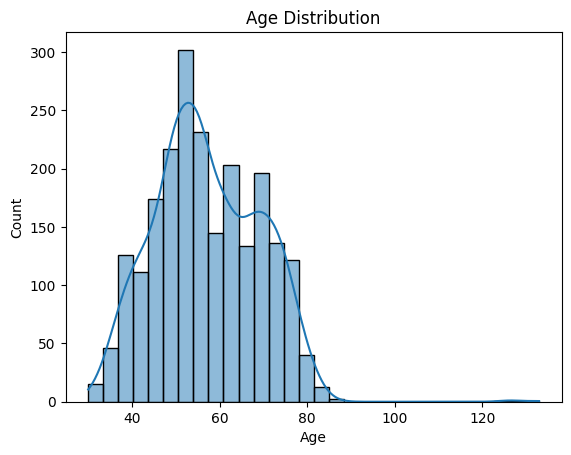

In [29]:
sns.histplot(df['Age'],bins=30,kde=True)
plt.title('Age Distribution')
plt.show()

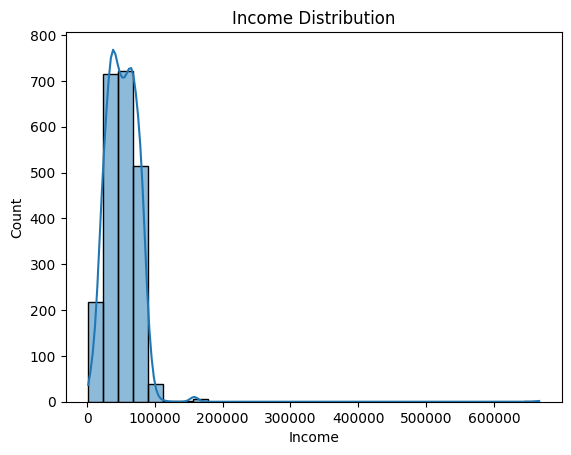

In [30]:
sns.histplot(df['Income'],bins=30,kde=True)
plt.title('Income Distribution')
plt.show()

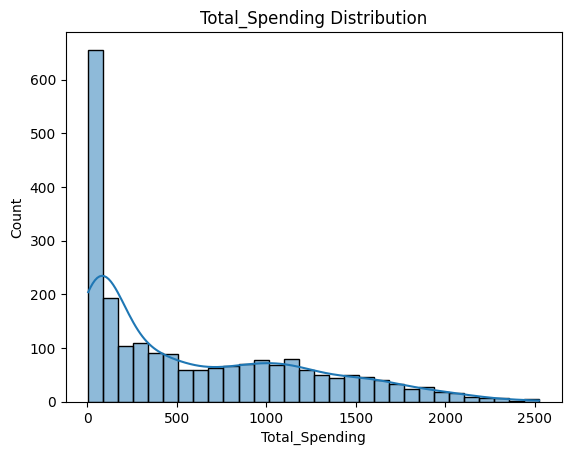

In [31]:
sns.histplot(df['Total_Spending'],bins=30,kde=True)
plt.title('Total_Spending Distribution')
plt.show()

Text(0.5, 1.0, 'Incom By Education Level')

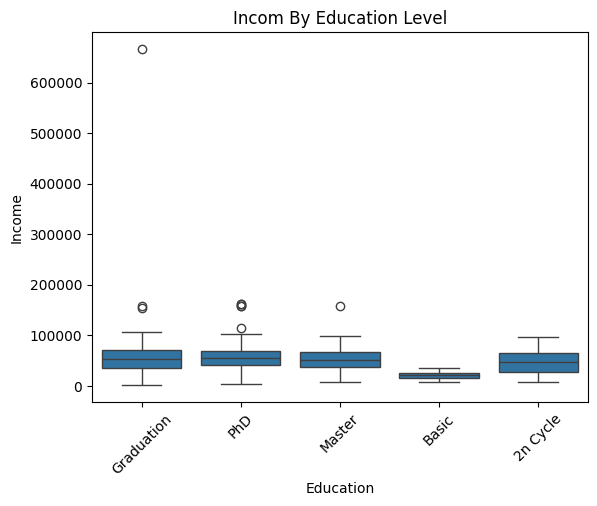

In [32]:
sns.boxplot(x="Education",y="Income",data=df)
plt.xticks(rotation=45)
plt.title("Incom By Education Level")

Text(0.5, 1.0, ' Spending By Marital_Status')

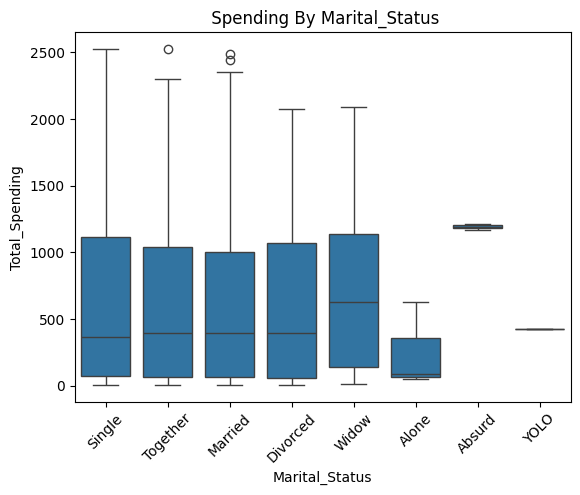

In [33]:
sns.boxplot(x="Marital_Status",y="Total_Spending",data=df)
plt.xticks(rotation=45)
plt.title(" Spending By Marital_Status")

In [34]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Childern', 'Total_Spending', 'Customer_since'],
      dtype='object')

In [35]:
corr=df[['Income','Age','Recency','NumWebPurchases','Total_Spending','NumStorePurchases']].corr()
corr

,Income,Age,Recency,NumWebPurchases,Total_Spending,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.387878,0.667576,0.529362
Age,0.161791,1.000000,0.016295,0.153051,0.113487,0.127891
Recency,-0.003970,0.016295,1.000000,-0.005641,0.020066,-0.000434
NumWebPurchases,0.387878,0.153051,-0.005641,1.000000,0.528973,0.516240
Total_Spending,0.667576,0.113487,0.020066,0.528973,1.000000,0.675181
NumStorePurchases,0.529362,0.127891,-0.000434,0.516240,0.675181,1.000000


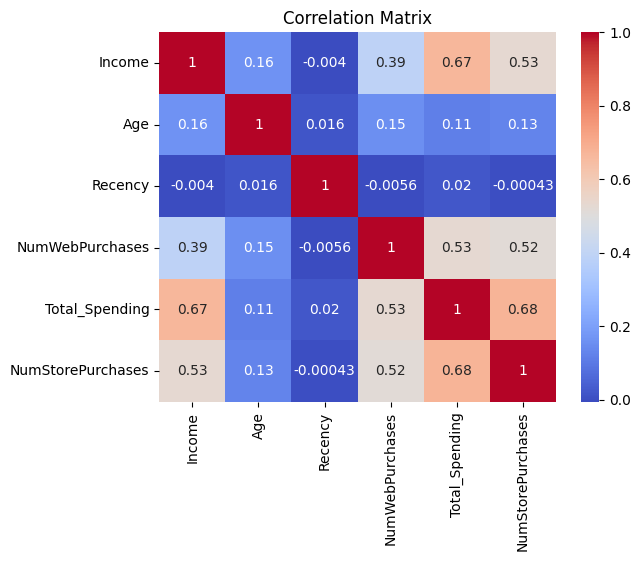

In [36]:
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [37]:
group1=df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)

group1

,Total_Spending
Education,
PhD,676.733888
Graduation,621.686380
Master,609.767123
2n Cycle,494.930000
Basic,81.796296


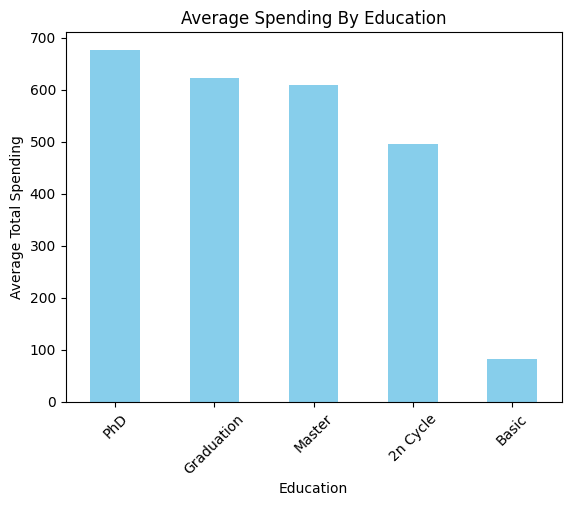

In [38]:
group1.plot(kind="bar",color="skyblue")
plt.title("Average Spending By Education")
plt.xlabel("Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.show()

In [39]:
#lazm " "
df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]]


,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
0,0,0,0,0,0,1
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
2235,0,0,0,0,0,0
2236,1,0,0,0,0,0
2237,0,0,0,1,0,0
2238,0,0,0,0,0,0


In [40]:
#lazm " "
df["AcceptedAny"]=df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]].sum(axis=1)
#lazm " "
df["AcceptedAny"]

,AcceptedAny
0,1
1,0
2,0
3,0
4,0
...,...
2235,0
2236,1
2237,1
2238,0


In [41]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [42]:
df["AcceptedAny"]=df["AcceptedAny"].apply(lambda x:1 if x>=1 else 0)
df["AcceptedAny"]

,AcceptedAny
0,1
1,0
2,0
3,0
4,0
...,...
2235,0
2236,1
2237,1
2238,0


In [43]:
group2=df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)
group2

,AcceptedAny
Marital_Status,
Absurd,0.500000
YOLO,0.500000
Widow,0.342105
Alone,0.333333
Single,0.312102
Divorced,0.297414
Married,0.252042
Together,0.251309


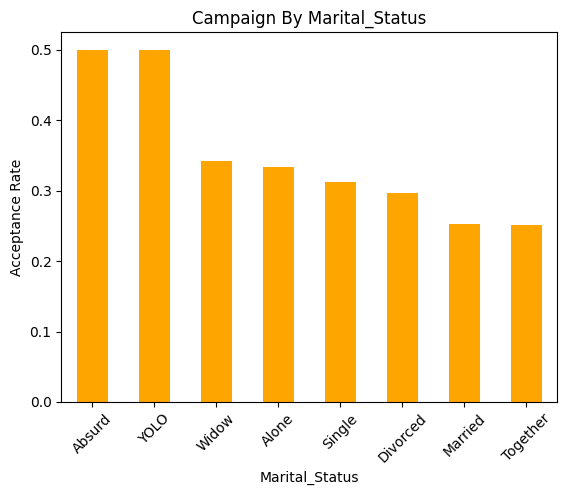

In [44]:
group2.plot(kind="bar",color="orange")
plt.title("Campaign By Marital_Status")

plt.ylabel("Acceptance Rate")
plt.xlabel("Marital_Status")
plt.xticks(rotation=45)
plt.show()

In [45]:
import pandas as pd

# Define the boundaries for the age bins
bins = [18, 30, 40, 50, 60, 70, 90]

# Define the names/labels for those bins
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]





In [46]:
# Create a new column 'AgeGroup' by cutting the 'Age' column
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [47]:
df["AgeGroup"]

,AgeGroup
0,60-69
1,70+
2,60-69
3,40-49
4,40-49
...,...
2235,50-59
2236,70+
2237,40-49
2238,60-69


In [48]:

# Group the data by the newly created AgeGroup
group3 = df.groupby("AgeGroup")["Income"].mean()

/tmp/ipython-input-345806339.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby("AgeGroup")["Income"].mean()


In [49]:
group3

,Income
AgeGroup,
18-29,10960.500000
30-39,47905.475676
40-49,48057.587649
50-59,50479.321534
60-69,55980.030928
70+,58767.083102


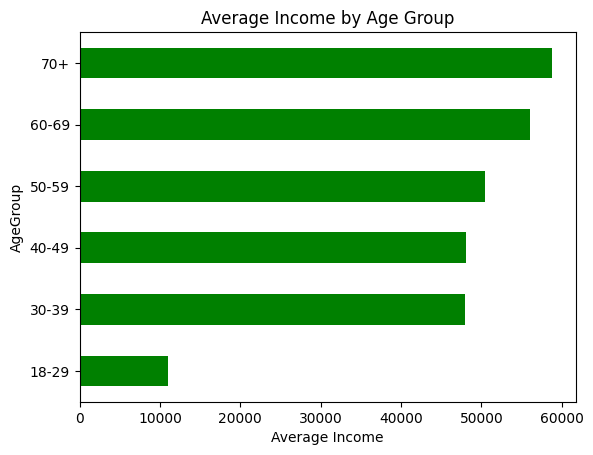

In [50]:
import matplotlib.pyplot as plt

# Plotting the horizontal bar chart
group3.plot(kind="barh", color="green")

# Adding chart details
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")

# The final line to display the plot
plt.show()

### A

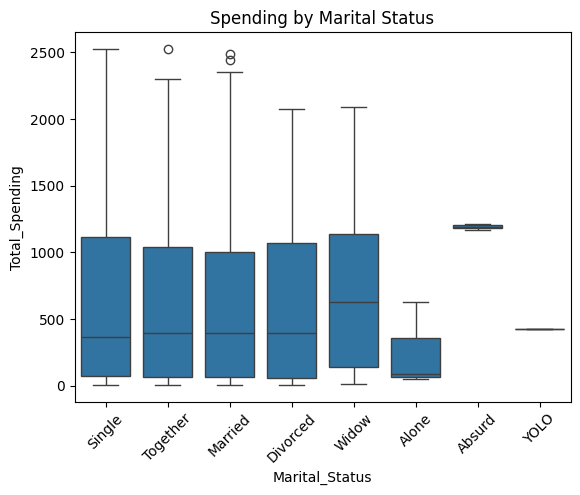

In [51]:
plt.figure()
sns.boxplot(x="Marital_Status", y="Total_Spending", data=df)
plt.xticks(rotation=45)
plt.title("Spending by Marital Status")
plt.show()

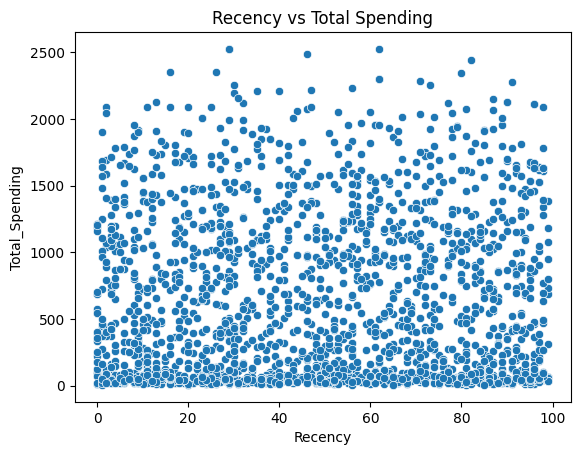

In [53]:
plt.figure()
sns.scatterplot(x="Recency", y="Total_Spending", data=df)
plt.title("Recency vs Total Spending")
plt.show()

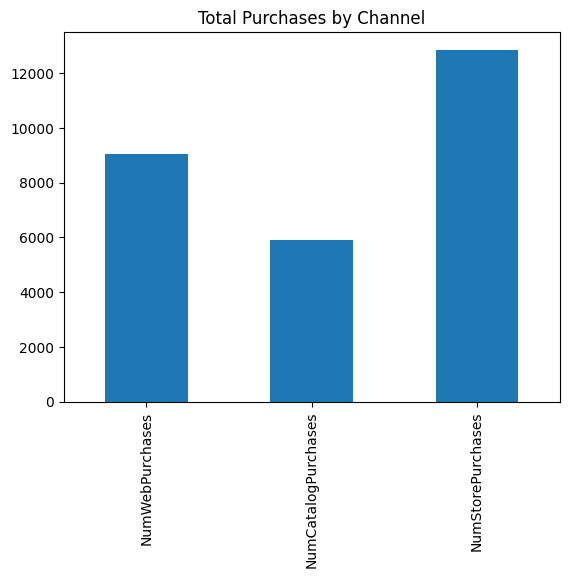

In [54]:
channels = ["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]

df[channels].sum().plot(kind="bar")
plt.title("Total Purchases by Channel")
plt.show()

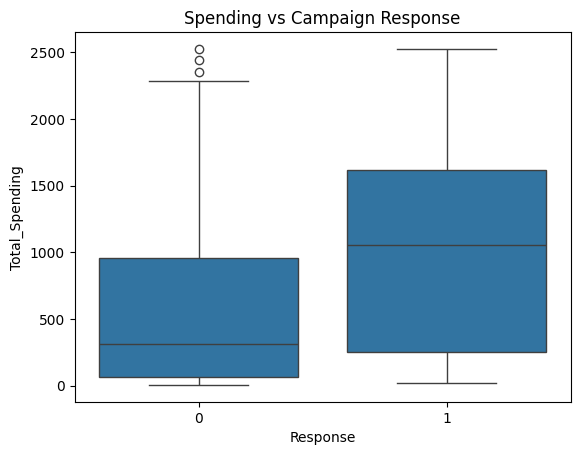

In [55]:
plt.figure()
sns.boxplot(x="Response", y="Total_Spending", data=df)
plt.title("Spending vs Campaign Response")
plt.show()

In [56]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Childern,Total_Spending,Customer_since,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,0,1617,4915,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,2,27,4365,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,0,776,4564,0,60-69
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,1,53,4391,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,1,422,4413,0,40-49


In [57]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Childern', 'Total_Spending', 'Customer_since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [58]:
feature=["Age","Income","Total_Spending","NumWebPurchases","NumStorePurchases","NumWebVisitsMonth","Recency"]

In [59]:
X=df[feature].copy()

In [60]:

X


,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,69,58138.0,1617,8,4,7,58
1,72,46344.0,27,1,2,5,38
2,61,71613.0,776,8,10,4,26
3,42,26646.0,53,2,4,6,26
4,45,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,59,61223.0,1341,9,4,5,46
2236,80,64014.0,444,8,5,7,56
2237,45,56981.0,1241,2,13,6,91
2238,70,69245.0,843,6,10,3,8


In [61]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit to the data and transform it
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]])

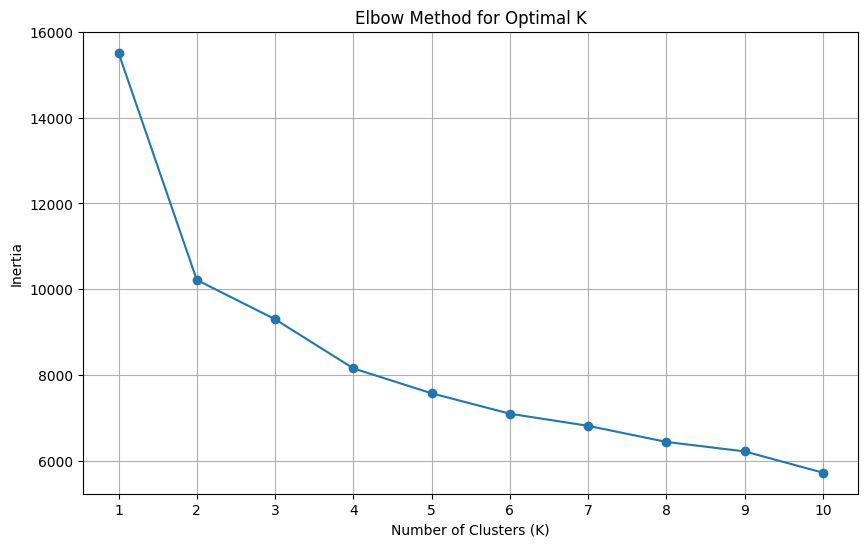

In [62]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Initialize a list to store the inertia values
inertia = []

# Define a range of clusters to test
k_range = range(1, 11) # Typically test from 1 to 10 clusters

# Loop through the range of clusters
for k in k_range:
    # Initialize KMeans with the current number of clusters
    # Use n_init='auto' to suppress the warning about default n_init
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    # Fit KMeans to the scaled data
    kmeans.fit(X_scaled)
    # Append the inertia to the list
    inertia.append(kmeans.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [63]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
df['Cluster'] = kmeans.fit_predict(X_scaled)
print(df['Cluster'].value_counts())

Cluster
0    1158
1    1058
Name: count, dtype: int64


In [64]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])

# Print the score
print(f"The average Silhouette Score is: {silhouette_avg:.2f}")

The average Silhouette Score is: 0.32


In [65]:
from sklearn.decomposition import PCA

# Apply PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA results
X_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print("Shape of X_pca:", X_pca.shape)
print("First 5 rows of X_pca:")
print(X_pca.head())

Shape of X_pca: (2216, 2)
First 5 rows of X_pca:
        PC1       PC2
0  1.107519 -0.211760
1 -1.336734  0.269839
2  1.882277 -1.014161
3 -1.784359 -0.704928
4  0.020363  1.235265


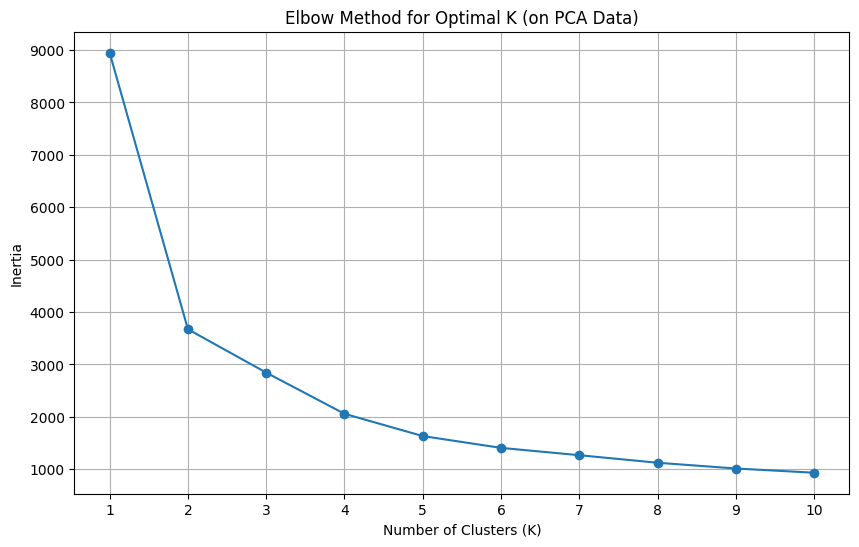

In [66]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Initialize a list to store the inertia values for PCA data
inertia_pca = []

# Define a range of clusters to test
k_range_pca = range(1, 11) # Typically test from 1 to 10 clusters

# Loop through the range of clusters
for k in k_range_pca:
    # Initialize KMeans with the current number of clusters
    kmeans_pca = KMeans(n_clusters=k, random_state=42, n_init='auto')
    # Fit KMeans to the PCA scaled data
    kmeans_pca.fit(X_pca)
    # Append the inertia to the list
    inertia_pca.append(kmeans_pca.inertia_)

# Plot the elbow method graph for PCA data
plt.figure(figsize=(10, 6))
plt.plot(k_range_pca, inertia_pca, marker='o')
plt.title('Elbow Method for Optimal K (on PCA Data)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range_pca)
plt.grid(True)
plt.show()

In [67]:
from sklearn.cluster import KMeans

kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init='auto')
df['Cluster_PCA'] = kmeans_pca.fit_predict(X_pca)

print("Distribution of clusters based on PCA data:")
print(df['Cluster_PCA'].value_counts())

Distribution of clusters based on PCA data:
Cluster_PCA
0    1164
1    1052
Name: count, dtype: int64


In [68]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score for PCA clusters
silhouette_avg_pca = silhouette_score(X_pca, df['Cluster_PCA'])

# Print the score
print(f"The average Silhouette Score for PCA clusters is: {silhouette_avg_pca:.2f}")

The average Silhouette Score for PCA clusters is: 0.51


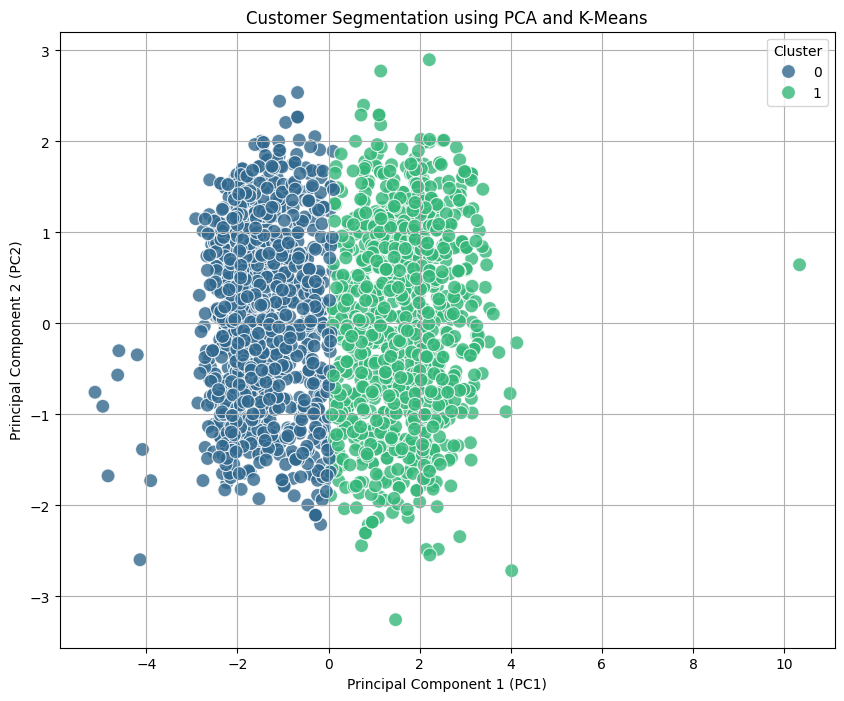

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add the Cluster_PCA labels to the X_pca DataFrame for easy plotting
X_pca['Cluster_PCA'] = df['Cluster_PCA'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster_PCA', data=X_pca, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segmentation using PCA and K-Means')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [70]:
from sklearn.pipeline import Pipeline
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Create pipeline with PCA
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("kmeans", KMeans(n_clusters=2, random_state=42))
])

# Train pipeline
pipeline.fit(X)

# Get cluster labels
labels = pipeline.predict(X)

# Get transformed data (after scaler + PCA)
X_transformed = pipeline[:-1].transform(X)

# Calculate silhouette score
score = silhouette_score(X_transformed, labels)

print("Silhouette Score:", score)

# Save pipeline
joblib.dump(pipeline, "customer_segmentation.pkl")

Silhouette Score: 0.5068759430709655


['customer_segmentation.pkl']

In [71]:
"""
import joblib

# Save the trained K-Means model
joblib.dump(kmeans_pca, "kmeans_model.pkl")

# Save the pca
joblib.dump(pca, "pca.pkl")

# Save the scaler (essential for processing new data the same way)
joblib.dump(scaler, "scaler.pkl")
"""

'\nimport joblib\n\n# Save the trained K-Means model\njoblib.dump(kmeans_pca, "kmeans_model.pkl")\n\n# Save the pca \njoblib.dump(pca, "pca.pkl")\n\n# Save the scaler (essential for processing new data the same way)\njoblib.dump(scaler, "scaler.pkl")\n'